# Preprocessing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyinform.utils import coalesce_series, coalesce
from pyinform import transfer_entropy
import networkx as nx
from scipy import stats
import sys
print(sys.executable)

c:\Users\taoni\Documents\jc\venv\Scripts\python.exe


### Load data

In [2]:
data = np.genfromtxt("data.csv", delimiter=",")

# 1 Data normalization

[  5.21560352   6.09997621  13.02125436 ...  34.0496583  -12.15346486
  17.27890364]


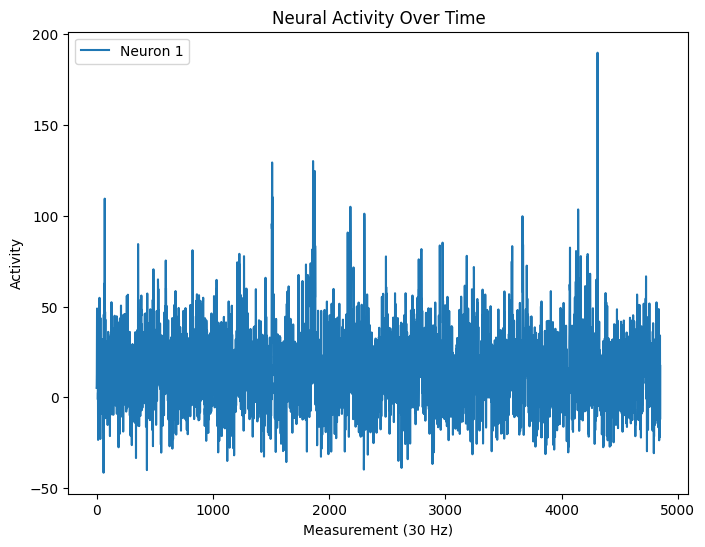

In [10]:
# Neuronal activity for neuron 1
print(data[0])

# Plot data for neuron 1
plt.figure(figsize=(8, 6))
plt.plot(np.arange(0, data.shape[1]), data[0,:], label="Neuron 1")
# plt.plot(np.arange(0, data.shape[1]), data[1,:], label="Neuron 2")
# plt.plot(np.arange(0, data.shape[1]), data[2,:], label="Neuron 3")
# plt.plot(np.arange(0, data.shape[1]), data[3,:], label="Neuron 4")
# plt.plot(np.arange(0, data.shape[1]), data[4,:], label="Neuron 5")

plt.xlabel("Measurement (30 Hz)")
plt.ylabel("Activity")
plt.title("Neural Activity Over Time")
plt.legend()
plt.show()

In [ ]:
# Relative change normalization (deltaF/F0)
window_size = 300
n_neurons, n_frames = data.shape

norm_data = np.zeros_like(data, dtype=float)

for i in range(n_neurons):
# for i in range(1):
    neuron = data[i]
    for t in range(n_frames):
        start = max(0, t - window_size)
        if t == 0:
            F0 = neuron[0]
        else:
            window = neuron[start:t]
            if window.size <= 1:
                F0 = neuron[0]
            else:
                median = np.percentile(window, 50)
                lower_half = window[window < median]
                F0 = np.mean(lower_half)
        if F0 == 0:
            F0 = 1e-6
        norm_data[i, t] = (neuron[t] - F0) / F0
    print(f"Neuron {i+1} normalized")

Neuron 1 normalized.
Neuron 2 normalized.
Neuron 3 normalized.
Neuron 4 normalized.
Neuron 5 normalized.
Neuron 6 normalized.
Neuron 7 normalized.
Neuron 8 normalized.
Neuron 9 normalized.
Neuron 10 normalized.
Neuron 11 normalized.
Neuron 12 normalized.
Neuron 13 normalized.
Neuron 14 normalized.
Neuron 15 normalized.
Neuron 16 normalized.
Neuron 17 normalized.
Neuron 18 normalized.
Neuron 19 normalized.
Neuron 20 normalized.
Neuron 21 normalized.
Neuron 22 normalized.
Neuron 23 normalized.
Neuron 24 normalized.
Neuron 25 normalized.
Neuron 26 normalized.
Neuron 27 normalized.
Neuron 28 normalized.
Neuron 29 normalized.
Neuron 30 normalized.
Neuron 31 normalized.
Neuron 32 normalized.
Neuron 33 normalized.
Neuron 34 normalized.
Neuron 35 normalized.
Neuron 36 normalized.
Neuron 37 normalized.
Neuron 38 normalized.
Neuron 39 normalized.
Neuron 40 normalized.
Neuron 41 normalized.
Neuron 42 normalized.
Neuron 43 normalized.
Neuron 44 normalized.
Neuron 45 normalized.
Neuron 46 normalize

In [7]:
# Write norm_data to csv
np.savetxt("norm_data.csv", norm_data, delimiter=",")

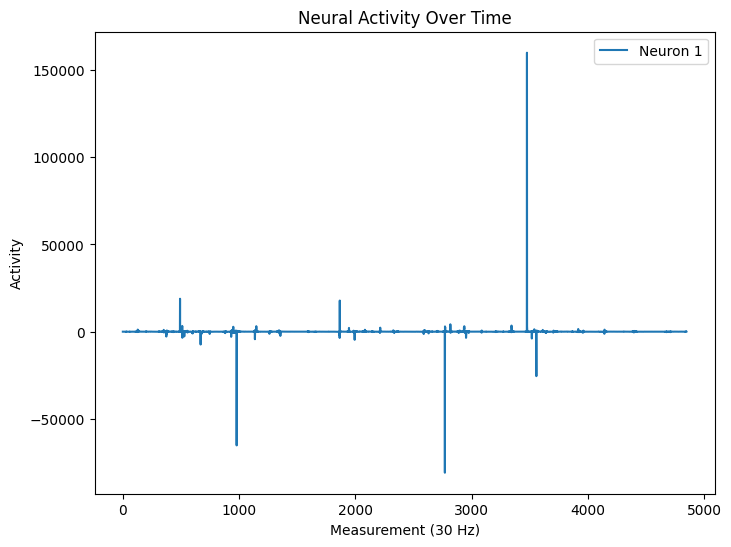

In [9]:
# Plot normalized data for neuron 1
plt.figure(figsize=(8, 6))
plt.plot(norm_data[0,:], label="Neuron 1")
plt.xlabel("Measurement (30 Hz)")
plt.ylabel("Activity")
plt.title("Neural Activity Over Time")
plt.legend()
plt.show()

In [ ]:
# Old z-score normalization
# mean = np.mean(data, axis=1, keepdims=True)
# std = np.std(data, axis=1, keepdims=True)
# norm_data = (data - mean) / std + 1

# 2 Pearson correlation

### 2.1 Correlation matrix

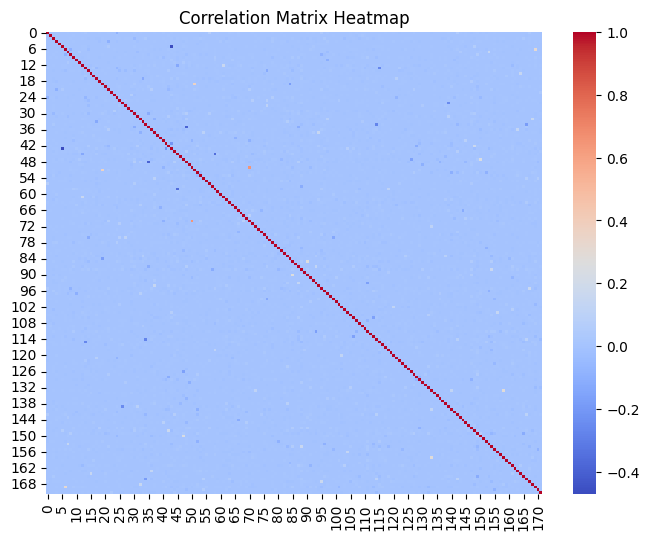

In [19]:
corr_matrix = np.corrcoef(norm_data)

# Plot correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Find maximum correlation, excluding 1s (correlation between neuron and itself)
# np.fill_diagonal(corr_matrix, -np.inf)
# print(corr_matrix.max())

### 2.2 Thresholded correlation matrix

In [29]:
# Analyze correlation matrix with different thresholds
for i in range(0, 5):
    corr_matrix = np.corrcoef(norm_data)

    # Remove self-correlations
    np.fill_diagonal(corr_matrix, 0)

    # Threshold weak correlations
    threshold = 0.01 * i
    corr_matrix[np.abs(corr_matrix) < threshold] = 0

    # Create undirected weighted graph
    G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)

    print(f"r > {threshold:.2f}: {G.number_of_edges()} edges")

r > 0.00: 29412 edges
r > 0.01: 1900 edges
r > 0.02: 766 edges
r > 0.03: 464 edges
r > 0.04: 330 edges


In [30]:
for i in range(5, 20):
    corr_matrix = np.corrcoef(norm_data)

    # Remove self-correlations
    np.fill_diagonal(corr_matrix, 0)

    # Threshold weak correlations
    threshold = 0.01 * i
    corr_matrix[np.abs(corr_matrix) < threshold] = 0

    # Create undirected weighted graph
    G = nx.from_numpy_array(corr_matrix, create_using=nx.DiGraph)

    pos = nx.spring_layout(G, seed=42)

    # nx.draw(G, pos, node_color='skyblue', node_size=100)

    # nx.draw_networkx_edges(G, pos, width=2, edge_color='black')

    # plt.title(f"Thresholded Pearson Correlation Network (r > {threshold:.2f})")
    # plt.show()

    print(f"r > {threshold:.2f}: {G.number_of_edges()} edges")
    nx.write_graphml(G, f"neurons{threshold*100:.0f}.graphml")

r > 0.05: 246 edges
r > 0.06: 196 edges
r > 0.07: 164 edges
r > 0.08: 140 edges
r > 0.09: 118 edges
r > 0.10: 96 edges
r > 0.11: 82 edges
r > 0.12: 70 edges
r > 0.13: 62 edges
r > 0.14: 52 edges
r > 0.15: 46 edges
r > 0.16: 42 edges
r > 0.17: 30 edges
r > 0.18: 28 edges
r > 0.19: 26 edges


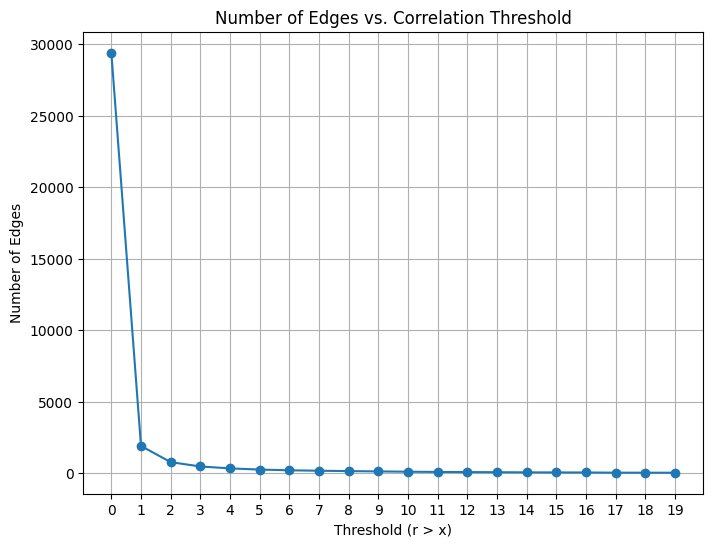

In [33]:
num_edges = [29412, 1900, 766, 464, 330, 246, 196, 164, 140, 118, 96, 82, 70, 62, 52, 46, 42, 30, 28, 26]

plt.figure(figsize=(8, 6))
plt.plot(range(0, 20), num_edges, marker='o')
plt.xlabel('Threshold (r > x)')
plt.ylabel('Number of Edges')
plt.title('Number of Edges vs. Correlation Threshold')
plt.xticks(range(0, 20))
plt.grid()
plt.show()

# *** All code past this point was not used for community detection ***

### 2.3 p-value analysis

Calculated p-values for neuron 1
Calculated p-values for neuron 11
Calculated p-values for neuron 21
Calculated p-values for neuron 31
Calculated p-values for neuron 41
Calculated p-values for neuron 51
Calculated p-values for neuron 61
Calculated p-values for neuron 71
Calculated p-values for neuron 81
Calculated p-values for neuron 91
Calculated p-values for neuron 101
Calculated p-values for neuron 111
Calculated p-values for neuron 121
Calculated p-values for neuron 131
Calculated p-values for neuron 141
Calculated p-values for neuron 151
Calculated p-values for neuron 161
Calculated p-values for neuron 171


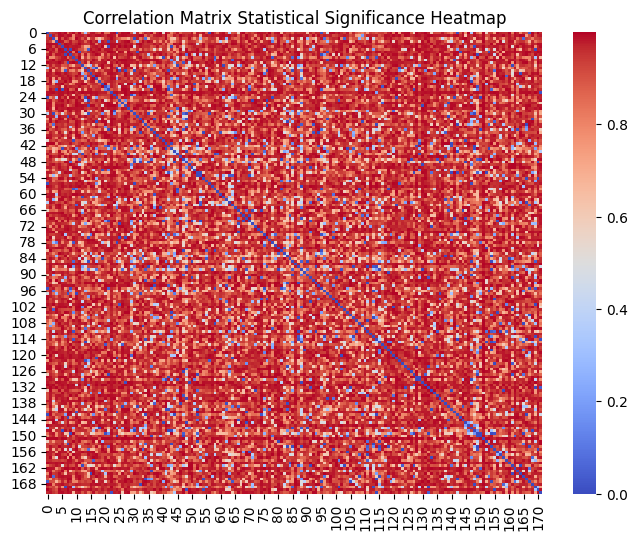

In [20]:
# Output a matrix with calculated p-values for the correlation matrix
n_neurons = norm_data.shape[0]
p_matrix = np.ones((n_neurons, n_neurons))
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        if i != j:
            p_matrix[i, j] = stats.pearsonr(norm_data[i], norm_data[j])[1]
    if i % 10 == 0:
        print(f"Calculated p-values for neuron {i+1}")

    p_matrix[i, i] = 0  # self-comparison
plt.figure(figsize=(8, 6))
sns.heatmap(p_matrix, cmap='coolwarm')
plt.title('Correlation Matrix Statistical Significance Heatmap')
plt.show()

# 3 Transfer entropy

### 3.1 Transfer entropy matrix

In [12]:
# Coalesce the series to positive integers for transfer entropy calculation in PyInform
def coalesce_row(row):
    # Returns (coalesced_row, base)
    return coalesce_series(row)[0]
coalesced_data = np.apply_along_axis(coalesce_row, 1, norm_data)

te_matrix = np.zeros((n_neurons, n_neurons))

k = 1  # history length

for i in range(n_neurons):
    for j in range(n_neurons):
        if i != j:
            te_matrix[i, j] = transfer_entropy(coalesced_data[i], coalesced_data[j], k=k)
    print(f"Calculated transfer entropy for neuron {i+1}")

# Transfer entropy matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(te_matrix, cmap='coolwarm')
plt.title('Transfer Entropy Matrix Heatmap')
plt.show()

KeyboardInterrupt: 

### 3.2 p-value analysis

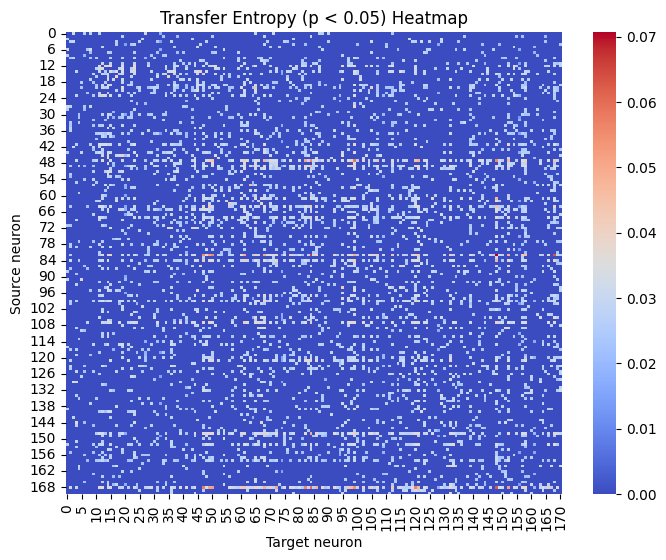

In [ ]:
# Now compute p-values using surrogate data
n_surrogates = 100
p_matrix = np.ones((n_neurons, n_neurons))

# Compute p-values for all pairs (i, j)
for i in range(n_neurons):
    for j in range(n_neurons):
        if i == j:
            continue
        source = coalesced_data[i]
        target = coalesced_data[j]
        true_te = te_matrix[i, j]
        null_dist = np.zeros(n_surrogates)
        for s in range(n_surrogates):
            shift = np.random.randint(len(source))
            surrogate = np.roll(source, shift)
            null_dist[s] = transfer_entropy(surrogate, target, k=1)
        p_matrix[i, j] = np.mean(null_dist >= true_te)
sig_te = np.where(p_matrix < 0.05, te_matrix, 0)

plt.figure(figsize=(8, 6))
sns.heatmap(sig_te, cmap='coolwarm')
plt.title('Transfer Entropy (p < 0.05) Heatmap')
plt.xlabel('Target neuron')
plt.ylabel('Source neuron')
plt.show()